#Time Evolution Block Decimation (TEBD) for spin-$1$ MPS from DMRG

Edited by [Min Long](https://quantummc.xyz/members/min-long/), November.2023.

Modified by [Hongyu Chen](https://quantummc.xyz/hongyuchern/) in July 2026.

Modified by [Hankun Zhang](https://quantummc.xyz/members/zhang-hankun/) in September 2026.

This notebook contains the dynamic properties of Heisenberg chain in the formalism of matrix product state(MPS).

The idea is that we want to calculate the time-dependence evolution of an arbitrary state (Of couse in MPS manifold), that is $e^{-i\hat{H}t}|\psi\rangle$.

The initial state $|\psi\rangle$ is prepared and written in MPS form in section 1 and 2. Then we want to write the time evolution operator in MPO(Matrix product operator form). Once we finish this construction, we can implement the calculation on the fly.

Firstly, we prepare the ground state, this process is copied from the file "DMRG_MPS".
For reference, reader can refer to the good review of Ulrich Schollwoeck [\[ref\]](https://arxiv.org/abs/1008.3477).

## 1. Ground state calculation [\[DMRG_MPS\]](https://colab.research.google.com/github/DavidGoing/DMRG/blob/main/DMRG_MPS.ipynb)

In [72]:
import numpy as np
import scipy
import scipy.sparse.linalg
import scipy.sparse as sparse
from time import perf_counter
import numpy.linalg as npla
import matplotlib.pyplot as plt
import copy
import math


## initial E and F matrices for the left and right vacuum states
def initial_E(W):
    E = np.zeros((W.shape[0], 1, 1))
    E[0] = 1
    return E


def initial_F(W):
    F = np.zeros((W.shape[1], 1, 1))
    F[-1] = 1
    return F


def contract_from_left(W, A, E, B):
    # the einsum function doesn't appear to optimize the contractions properly,
    # so we split it into individual summations in the optimal order
    # return np.einsum("abst,sij,aik,tkl->bjl",W,A,E,B, optimize=True)
    Temp = np.einsum("sij,aik->sajk", A, E)
    Temp = np.einsum("sajk,abst->tbjk", Temp, W)
    return np.einsum("tbjk,tkl->bjl", Temp, B.conjugate())

def contract_from_right(W, A, F, B):
    # the einsum function doesn't appear to optimize the contractions properly,
    # so we split it into individual summations in the optimal order
    # return np.einsum("abst,sij,bjl,tkl->aik",W,A,F,B, optimize=True)
    Temp = np.einsum("sij,bjl->sbil", A, F)
    Temp = np.einsum("sbil,abst->tail", Temp, W)
    return np.einsum("tail,tkl->aik", Temp, B.conjugate())


# construct the F-matrices for all sites except the first
def construct_F(Alist, MPO, Blist):
    F = [initial_F(MPO[-1])]
    for i in range(len(MPO) - 1, 0, -1):
        F.append(contract_from_right(MPO[i], Alist[i], F[-1], Blist[i]))
    return F


def construct_E(Alist, MPO, Blist):
    return [initial_E(MPO[0])]

def Expectation(AList, MPO, BList):
    E = [[[1]]]
    for i in range(0, len(MPO)):
        E = contract_from_left(MPO[i], AList[i], E, BList[i])
    return E[0][0][0]


# 2-1 coarse-graining of two site MPO into one site
def coarse_grain_MPO(W, X):
    return np.reshape(np.einsum("abst,bcuv->acsutv", W, X),
                      [W.shape[0], X.shape[1],
                       W.shape[2] * X.shape[2],
                       W.shape[3] * X.shape[3]])


def product_W(W1, W2):
    return np.reshape(np.einsum("abst,cdtu->acbdsu", W1, W2), [W1.shape[0] * W2.shape[0],
                                                               W1.shape[1] * W2.shape[1],
                                                               W1.shape[2], W2.shape[3]])


def product_MPO(M1, M2):
    assert len(M1) == len(M2)
    Result = []
    for i in range(0, len(M1)):
        Result.append(product_W(M1[i], M2[i]))
    return Result


# 2-1 coarse-graining of two-site MPS into one site
def coarse_grain_MPS(A, B):
    return np.reshape(np.einsum("sij,tjk->stik", A, B),
                      [A.shape[0] * B.shape[0], A.shape[1], B.shape[2]])


def fine_grain_MPS(A, dims):
    assert A.shape[0] == dims[0] * dims[1]
    Theta = np.transpose(np.reshape(A, dims + [A.shape[1], A.shape[2]]),
                         (0, 2, 1, 3))
    M = np.reshape(Theta, (dims[0] * A.shape[1], dims[1] * A.shape[2]))
    U, S, V = np.linalg.svd(M, full_matrices=0)
    U = np.reshape(U, (dims[0], A.shape[1], -1))
    V = np.transpose(np.reshape(V, (-1, dims[1], A.shape[2])), (1, 0, 2))
    # assert U is left-orthogonal
    # assert V is right-orthogonal
    # print(np.dot(V[0],np.transpose(V[0])) + np.dot(V[1],np.transpose(V[1])))
    return U, S, V

def truncate_MPS(U, S, V, m):
    m = min(len(S), m)
    trunc = np.sum(S[m:])
    S = S[0:m]
    U = U[:, :, 0:m]
    V = V[:, 0:m, :]
    return U, S, V, trunc, m


class HamiltonianMultiply(sparse.linalg.LinearOperator):
    def __init__(self, E, W, F):
        self.E = E
        self.W = W
        self.F = F
        self.dtype = np.dtype('d')
        self.req_shape = [W.shape[2], E.shape[1], F.shape[1]]
        # self.req_shape = [W.shape[2], E.shape[1], F.shape[2]] ORIGINAL VERSION
        self.size = self.req_shape[0] * self.req_shape[1] * self.req_shape[2]
        self.shape = [self.size, self.size]

    def _matvec(self, A):
        # the einsum function doesn't appear to optimize the contractions properly,
        # so we split it into individual summations in the optimal order
        # R = np.einsum("aij,sik,abst,bkl->tjl",self.E,np.reshape(A, self.req_shape),
        #              self.W,self.F, optimize=True)
        R = np.einsum("aij,sik->ajsk", self.E, np.reshape(A, self.req_shape))
        R = np.einsum("ajsk,abst->bjtk", R, self.W)
        R = np.einsum("bjtk,bkl->tjl", R, self.F)
        return np.reshape(R, -1)


## optimize a single site given the MPO matrix W, and tensors E,F
def optimize_site(A, W, E, F):
    H = HamiltonianMultiply(E, W, F)
    # we choose tol=1E-8 here, which is OK for small calculations.
    # to bemore robust, we should take the tol -> 0 towards the end
    # of the calculation.
    E, V = sparse.linalg.eigsh(H, 1, v0=A, which='SA', tol=1E-8)
    return (E[0], np.reshape(V[:, 0], H.req_shape))


def optimize_two_sites(A, B, W1, W2, E, F, m, dir):
    W = coarse_grain_MPO(W1, W2)
    AA = coarse_grain_MPS(A, B)
    H = HamiltonianMultiply(E, W, F)
    E, V = sparse.linalg.eigsh(H, 1, v0=AA, which='SA')
    AA = np.reshape(V[:, 0], H.req_shape)
    A, S, B = fine_grain_MPS(AA, [A.shape[0], B.shape[0]])
    A, S, B, trunc, m = truncate_MPS(A, S, B, m)
    if (dir == 'right'):
        B = np.einsum("ij,sjk->sik", np.diag(S), B)
    else:
        assert dir == 'left'
        A = np.einsum("sij,jk->sik", A, np.diag(S))
    return E[0], A, B, trunc, m


def two_site_dmrg(MPS, MPO, m, sweeps):
    E = construct_E(MPS, MPO, MPS)
    F = construct_F(MPS, MPO, MPS)
    F.pop()
    for sweep in range(0, int(sweeps / 2)):
        for i in range(0, len(MPS) - 2):
            Energy, MPS[i], MPS[i + 1], trunc, states = optimize_two_sites(MPS[i], MPS[i + 1],
                                                                           MPO[i], MPO[i + 1],
                                                                           E[-1], F[-1], m, 'right')
            print("Sweep {:} Sites {:},{:}    Energy {:16.12f}    States {:4} Truncation {:16.12f}"
                  .format(sweep * 2 + 1, i, i + 1, Energy, states, trunc))
            E.append(contract_from_left(MPO[i], MPS[i], E[-1], MPS[i]))
            F.pop();
        for i in range(len(MPS) - 2, 0, -1):
            Energy, MPS[i], MPS[i + 1], trunc, states = optimize_two_sites(MPS[i], MPS[i + 1],
                                                                           MPO[i], MPO[i + 1],
                                                                           E[-1], F[-1], m, 'left')
            print("Sweep {} Sites {},{}    Energy {:16.12f}    States {:4} Truncation {:16.12f}"
                  .format(sweep * 2 + 2, i, i + 1, Energy, states, trunc))
            F.append(contract_from_right(MPO[i + 1], MPS[i + 1], F[-1], MPS[i + 1]))
            E.pop();
    return MPS




d = 3  # local bond dimension
N = 32  # number of sites
D = 10

InitialA1 = np.zeros((d, 1, 1))
InitialA1[0, 0, 0] = 1
InitialA2 = np.zeros((d, 1, 1))
InitialA2[d-1, 0, 0] = 1

## initial state |01010101>
MPS = [InitialA1, InitialA2] * int(N / 2)
if N%2 != 0 :
    MPS = MPS + [InitialA1]

## Local operators
I = np.identity(d)
Z = np.zeros((d, d))
Sz = np.zeros((d, d))
Sp = np.zeros((d, d))
Sm = np.zeros((d, d))

sz_lsit = []

for i in range(d):
      sz_lsit.append(d/2 - i -1/2)

Sz = np.diag(sz_lsit)
Sz = Sz.astype('float64')
for i in range(d-1):
    Sp[i+1,i] = np.sqrt(d-1)
for i in range(d-1):
    Sm[i,i+1] = np.sqrt(d-1)
print('Spin chain with total Spin: {}'.format((d-1)/2))
print('Sz matrix form: \n =============')
print(Sz)
print('S+ matrix form: \n =============')
print(Sp)
print('S- matrix form: \n =============')
print(Sm)

Spin chain with total Spin: 1.0
Sz matrix form: 
[[ 1.  0.  0.]
 [ 0.  0.  0.]
 [ 0.  0. -1.]]
S+ matrix form: 
[[0.         0.         0.        ]
 [1.41421356 0.         0.        ]
 [0.         1.41421356 0.        ]]
S- matrix form: 
[[0.         1.41421356 0.        ]
 [0.         0.         1.41421356]
 [0.         0.         0.        ]]


In [73]:

## Hamiltonian MPO
W = np.array([[I, Sz, 0.5 * Sp, 0.5 * Sm, Z],
              [Z, Z, Z, Z, Sz],
              [Z, Z, Z, Z, Sm],
              [Z, Z, Z, Z, Sp],
              [Z, Z, Z, Z, I]])

Wfirst = np.array([[I, Sz, 0.5 * Sp, 0.5 * Sm, Z]])

Wlast = np.array([[Z], [Sz], [Sm], [Sp], [I]])

# the complete MPO
MPO = [Wfirst] + ([W] * (N - 2)) + [Wlast]

HamSquared = product_MPO(MPO, MPO)

Gs = two_site_dmrg(MPS, MPO, D, 8)

Energy = Expectation(Gs, MPO, Gs)
print("Final energy expectation value {}".format(Energy))

H2 = Expectation(Gs, HamSquared, Gs)
print("variance = {:16.12f}".format(H2 - Energy * Energy))

Sweep 1 Sites 0,1    Energy -31.481194304092    States    3 Truncation   0.000000000000
Sweep 1 Sites 1,2    Energy -31.827550196615    States    3 Truncation   0.000000000000
Sweep 1 Sites 2,3    Energy -32.203481362554    States    3 Truncation   0.000000000000
Sweep 1 Sites 3,4    Energy -32.567121450138    States    3 Truncation   0.000000000000
Sweep 1 Sites 4,5    Energy -32.932138072781    States    3 Truncation   0.000000000000
Sweep 1 Sites 5,6    Energy -33.295992885665    States    3 Truncation   0.000000000000
Sweep 1 Sites 6,7    Energy -33.659816720597    States    3 Truncation   0.000000000000
Sweep 1 Sites 7,8    Energy -34.023503340587    States    3 Truncation   0.000000000000
Sweep 1 Sites 8,9    Energy -34.387163904762    States    3 Truncation   0.000000000000
Sweep 1 Sites 9,10    Energy -34.750804560921    States    3 Truncation   0.000000000000
Sweep 1 Sites 10,11    Energy -35.114438977516    States    3 Truncation   0.000000000000
Sweep 1 Sites 11,12    Energy

## 2. Benchmark of ground state [\[DMRG_MPS\]](https://colab.research.google.com/github/DavidGoing/DMRG/blob/main/DMRG_MPS.ipynb)
Above code perform ground state searching using 2-sites DMRG, detailed explanation can be refered in the DMRG_MPS notebook,  before proceeding to time evolution, we benchmark our ground state and implement some basic operations we will perform on MPS.

We want to measure the correlation function $\langle S(x)S(0)\rangle$ for ground state, we already know that this correlation funtion is expotentially decay. Due to the antiferremagnetic ground state, the correlation function also bear the feature that it is oscillating beteen the positive and negative value.

Below I implement some basic function which perform measurement and inner product of MPS.

Reader should already familiar with these operations from the practice of ground state searching using MPS formalism.



################################################################
#                   Benchmark of groundstate #
################################################################


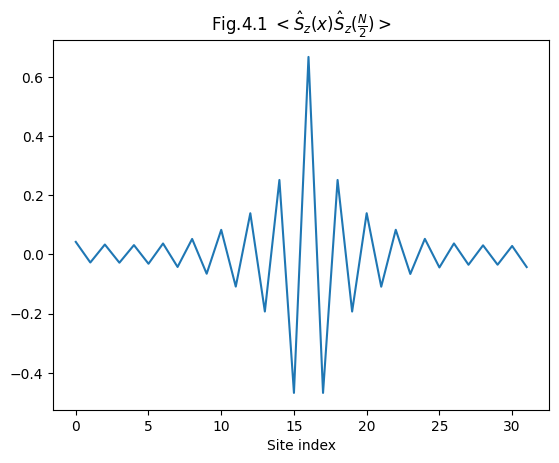

In [74]:

print('\n')
print(
    "################################################################\n"
    "#                   Benchmark of groundstate #\n"
    "################################################################"
)

def state_overlap(Co_List,Contro_List):
    R = [[1]]
    for i in range(0, len(Co_List)):
        R = np.einsum("ik,sij->skj",R,Co_List[i].conjugate())
        R = np.einsum("skj,skl->jl",R,Contro_List[i])
    return R[0][0]


def state_overlap_from_left(Co_List,Contro_List):
    R = [[1]]
    for i in range( 0, len(Co_List)):
        R = np.einsum("ik,sij->skj",R,Co_List[i])
        R = np.einsum("skj,skl->jl",R,Contro_List[i].conjugate())
    return R[0][0]

# def multi_site_measurement(MPS1,MPS2,op_list,pos_list):
#     idx = np.argsort(pos_list)
#     pos_list = np.array(pos_list)[idx]
#     op_list = np.array(op_list)[idx]
#     expectation = [[1]]
#     # print(op_list,pos_list)
#     assert len(op_list) == len(pos_list)
#     for j in range(0, pos_list[0]):
#         expectation = np.einsum("ik,sij->skj", expectation, MPS1[j])
#         expectation = np.einsum("skj,skl->jl",  expectation,MPS2[j].conjugate())
#     expectation = np.einsum('ik,sij,st,tkl->jl', expectation, MPS1[pos_list[0]], op_list[0], MPS2[pos_list[0]].conjugate())
#     for i in range(len(op_list)-1):
#         for j in range(pos_list[i]+1,pos_list[i+1]):
#             expectation = np.einsum("ik,sij->skj", expectation, MPS1[j])
#             expectation = np.einsum("skj,skl->jl", expectation,MPS2[j].conjugate())
#         expectation = np.einsum('ik,sij,st,tkl->jl', expectation, MPS1[pos_list[i+1]], op_list[i+1], MPS2[pos_list[i+1]].conjugate())
#     for j in range(pos_list[-1]+1,len(MPS1)):
#         expectation = np.einsum("ik,sij->skj", expectation, MPS1[j])
#         expectation = np.einsum("skj,skl->jl", expectation,MPS2[j].conjugate())
#     return expectation[0][0]

def multi_site_measurement(MPS1, MPS2, op_list, pos_list):
    idx = np.argsort(pos_list)
    pos_list = np.array(pos_list)[idx]
    op_list = np.array(op_list)[idx]
    assert len(op_list) == len(pos_list)

    expectation = [[1]]
    k = 0
    for j in range(len(MPS1)):
        if k < len(pos_list) and j == pos_list[k]:
            expectation = np.einsum(
                'ik,sij,st,tkl->jl',
                expectation, MPS1[j], op_list[k], MPS2[j].conjugate(),
                optimize=True,
            )
            k += 1
        else:
            expectation = np.einsum(
                'ik,sij,skl->jl',
                expectation, MPS1[j], MPS2[j].conjugate(),
                optimize=True,
            )
    return expectation[0][0]


def plot_SzSz_correlation_MPS(MPS_in):
    SzSz_correlation = []
    for i in range(N):
        if i != N//2:
            SzSz_correlation.append(multi_site_measurement(MPS_in,Gs,[Sz,Sz],[i,N//2]))
        else:
            SzSz_correlation.append(multi_site_measurement(MPS_in, Gs, [Sz@Sz], [i]))
    plt.plot(SzSz_correlation)
    # plt.rcParams['font.family'] = 'Arial'
    plt.title(r"Fig.4.1 $<\hat{S}_z(x)\hat{S}_z(\frac{N}{2})>$")
    plt.xlabel("Site index")
    # plt.savefig("temp")
    plt.show()
    # plt.savefig("SzSz_correlation_measurement")
    plt.close()
plot_SzSz_correlation_MPS(Gs)
# quit()


## 3. Orthogonalization of MPS via transferring singular values

In practice, we usually use canonical forms to do calculation. The advantage of this form is that it is convenient to do truncation according to the singular values.

The canonical MPS is a kind of gauge condition, $i.e.$, orthogonal gauge. Notably, for a normal state's eigenvector, the measurement and orthogonality are both defined by inner product nothing but distinguished by an inserted observable-dependence operator. While in MPS manifold, things changed. The observable measurement is done by tensor product [see function state overlap and function multi_site_measurement] over all the system sites.     

Physically, the truncation at a site makes sense when all the left sites are of the left canonical form and all the right sides are of the right canonical form. Since in such cases the MPS can be view as combination of orthogonal states, which are the direct product of states from left subsystem and right subsystem. A typical one-site canonical MPS can be expressed as:
$$
|\Psi\rangle = \sum_i  A_1^{\sigma_1}A_2^{\sigma_2}...A_{n-1}^{\sigma_{n-1}}M_n^{\sigma_n}B_{n+1}^{\sigma_{n+1}}...B_{N}^{\sigma_{N}}  | \sigma_i\rangle
$$  
The cartoon for the left-canonical, right-canonical, zero-site mixed canonical, one-site mixed canonical and two-site mixed canonical MPS are shown below, where the squares store the singularity and the leftward/rightward triangulars represent the matrix of left/right sub-system A/B:
![Alt text](https://github.com/DavidGoing/DMRG/blob/main/figures/canonical.jpg?raw=true)

Then the truncation has clear physical meaning: We neglect the components which constitute small part of the total state.


Since everytime we do measurement or acting operators, there is possibility of bringing singular values. We have to move the mix caconical site to the site where we will operate to absorb the singular value.

**Below is an illustration on how to transfer singular values.**

![image.png](https://github.com/DavidGoing/DMRG/raw/main/figures/TEBD_moving_singular_values.png)
Initially, singular value is stored in $M_{a_1 a_2}^{\sigma_2}$

1. Reshape $M_{a_1 a_2}^{\sigma_2}$ into a matrix with the form $M_{(\sigma_1a_1),a_2}$, where $(\sigma_1a_1)$ is a composite index which has the dimenstion $Dim(\sigma_1)\times Dim(a_1)$ .
2. Perform SVD on the matrix, then it turns to $U_{(\sigma_1a_1),a_i}S_{a_i,a_j}V_{a_j,a_2}$.
3. From the basic properties of SVD, $A^{\sigma_1}_{a_1a_i} = U_{(\sigma_1a_1),a_i}$ is a left caconical matrix. We keep A in site 1.
4. Absorb S and V to $B^{\sigma_2}_{a_2a_3}$

Then the singular value transfer of between adjacent sites has been finished, for transfer more that one site, just do it interatively.


And the normalization of MPS could be caculated by:
$$
\sum_{\sigma_{i}}(A^{\sigma_i\dagger}A^{\sigma_i} + B^{\sigma_i}B^{\sigma_i\dagger}) = 1.
$$

In [75]:

# print("\n")
# print(
# "############################################################################\n\
# #                    Time evolution of Ground state using iTEBD            # \n\
# ############################################################################"
# )

def move_mix_site(start ,end , mix_MPS ,bond_dim):
    if end > start:
        move_dir = 'r'
        for i in range(start,end,1):
            M1 = mix_MPS[i]
            M_mat = np.reshape(M1,(M1.shape[0]*M1.shape[1],M1.shape[2]))
            A, S, B = np.linalg.svd(M_mat, full_matrices=0)
            trunc_dim = min(bond_dim,len(S))
            A = A[:,0:trunc_dim]
            S = S[0:trunc_dim]
            B = B[0:trunc_dim,:]
            # print(npla.norm(A@np.diag(S)@B-M_mat))
            trunc = np.sum(S[trunc_dim:])
            A = np.reshape(A,(M1.shape[0],M1.shape[1],-1))
            # print("Truncation error in moving from site {} to {} : {}".format(i,i+1,trunc))
            if trunc > 1e-10:
                raise Exception("large truncation error")
            B = np.diag(S)@B
            mix_MPS[i] =  A
            mix_MPS[i+1] = np.einsum("ij,sjk->sik",B,mix_MPS[i+1])
    if end < start:
        move_dir = 'l'
        for i in range(start,end,-1):
            M1 = mix_MPS[i]
            M_mat = np.reshape(M1.transpose(1,0,2), (M1.shape[1], M1.shape[0] * M1.shape[2]))
            A, S, B = np.linalg.svd(M_mat, full_matrices=0)
            trunc_dim = min(bond_dim, len(S))
            A = A[:, 0:trunc_dim]
            S = S[0:trunc_dim]
            B = B[0:trunc_dim, :]
            # print(npla.norm(A @ np.diag(S) @ B - M_mat))
            trunc = np.sum(S[trunc_dim:])
            B = np.reshape(B, (-1,M1.shape[0], M1.shape[2])).transpose(1,0,2)
            # print("Truncation error in moving from site {} to {} : {}".format(i, i + 1, trunc))
            if trunc > 1e-10:
                raise Exception("large truncation error")
            A = A@np.diag(S)
            mix_MPS[i] = B
            mix_MPS[i - 1] = np.einsum("sjk,kl->sjl", mix_MPS[i-1], A)
    if "move_dir" not in locals():
        raise Exception("Not standard input form, Nothing happend")
    return mix_MPS

def check_othogonal(MPS):
    infor_string = []
    for ten in MPS:
        matl = np.einsum("sij,sik->jk",ten,ten)
        matr = np.einsum("sij,slj->il",ten,ten)
        dim = matl.shape[0]
        Il = np.identity(dim)
        Ir = np.identity(matr.shape[0])
        if npla.norm(matl-Il)<1e-10:
            infor_string.append('A')
        if npla.norm(matr-Ir)<1e-10:
            infor_string.append('B')
        if not(npla.norm(matl-Il)<1e-10 or npla.norm(matr-Ir)<1e-10):
            infor_string.append('M')
    return ' '.join(infor_string)



In [76]:


print("Normalizatin check of Ground state",state_overlap(Gs,Gs))

tau =0.2
time_slice = 50
Evolution_Sz = np.zeros((time_slice+1,N),dtype=complex)
Correlation_SpSm = np.zeros((time_slice+1,N),dtype=complex)

MPSt = copy.deepcopy(Gs)


print("\n")
print(
    "##################################################\n"
    "#      Time evolution and perform measurement    #\n"
    "##################################################"
)



def orthogonize(M,bond_dim):
    M1 = copy.deepcopy(M)
    M_mat = np.reshape(M1, (M1.shape[0] * M1.shape[1], M1.shape[2]))
    A, S, B = np.linalg.svd(M_mat, full_matrices=0)
    trunc_dim = min(bond_dim, len(S))
    A = A[:, 0:trunc_dim]
    S = S[0:trunc_dim]
    B = B[0:trunc_dim, :]
    S = np.array(S)/np.sqrt(sum([abs(item)**2 for item in S]))
    M_mat = np.reshape(A@ np.diag(S) @B, (M1.shape[0] , M1.shape[1], M1.shape[2]))
    return M_mat

MPSt = move_mix_site(start=1,end=N//2, mix_MPS=MPSt,bond_dim=D)
MPSt[N//2] = np.einsum("sij,st->tij",MPSt[N//2],Sp)
MPSt[N//2] = orthogonize(MPSt[N//2],D)
MPSt = move_mix_site(start=N//2,end=1, mix_MPS=MPSt,bond_dim=D)


Normalizatin check of Ground state 0.9999999999999968


##################################################
#      Time evolution and perform measurement    #
##################################################


## 4. Time Evolution Block Decimation

Every time step we calculate $e^{-i\hat{H}\tau}$(This will bring a Trotter error proportional to $\tau$), where $\tau$ is the time step.

$$
e^{-i\hat{H}\tau} = \prod_{i = 0}^{i=L-1} e^{-i\tau(\hat{S_i}\hat{S_{i+1}})} + O(\tau)
$$

Where $O(\tau)$ is the error bring by the commutator.

In calculating every block we move on the singular values.
![image.png](https://github.com/DavidGoing/DMRG/raw/main/figures/TEBD_block_absorption.png)

In [77]:


print('############################')

start = perf_counter()
for i in range(N):
    Evolution_Sz[0,i] = multi_site_measurement(MPSt,MPSt,[Sz],[i])
    Correlation_SpSm[0,i] = multi_site_measurement(MPSt,Gs,[Sm],[i])


Coupled_operator = np.einsum("st,kl-> sktl",Sz,Sz)
Coupled_operator += 0.5*np.einsum("st,kl-> sktl",Sp,Sm)
Coupled_operator += 0.5*np.einsum("st,kl-> sktl",Sm,Sp)
Exp_Coupled = np.reshape(Coupled_operator,(d**2,d**2))
Exp_Coupled = scipy.linalg.expm(complex(0,-tau)*Exp_Coupled)

for t in range(time_slice//2):
    for i in range(0,N-1,1):
        MM = coarse_grain_MPS(MPSt[i], MPSt[i+1])
        image = np.einsum("st,sij->tij",Exp_Coupled,MM)
        A, S, B = fine_grain_MPS(image, [MPSt[i].shape[0], MPSt[i + 1].shape[0]])
        A, S, B, trunc, m = truncate_MPS(A, S, B, D)
        # print(trunc)
        B = np.einsum("ij,sjk->sik",  np.diag(S),B)
        MPSt[i], MPSt[i + 1]  = A,B
    for i in range(N):
        Evolution_Sz[t*2+1 , i] = multi_site_measurement(MPSt,MPSt,[Sz],[i])
        Correlation_SpSm[t*2+1 , i] = multi_site_measurement(MPSt,Gs,[Sm],[i])
    for i in range(N-1,0,-1):
        MM = coarse_grain_MPS(MPSt[i-1], MPSt[i ])
        image = np.einsum("st,sij->tij", Exp_Coupled, MM)
        A, S, B = fine_grain_MPS(image, [MPSt[i-1].shape[0], MPSt[i ].shape[0]])
        A, S, B, trunc, m = truncate_MPS(A, S, B, D)
        # print(trunc)
        A = np.einsum("sij,jk->sik", A, np.diag(S))
        MPSt[i - 1],MPSt[i ] = A,B
    for i in range(N):
        Evolution_Sz[2*t+2 , i] = multi_site_measurement(MPSt,MPSt,[Sz],[i])
        Correlation_SpSm[2*t+2 , i] = multi_site_measurement(MPSt,Gs,[Sm],[i])
end = perf_counter()
print('time used in time evolution: {:.2f}s'.format(end-start))



############################
time used in time evolution: 16.31s



The time-evolved MPS is $|\Psi(t) = e^{-i\hat{H}\tau}|Gs\rangle$, as we do the measurement:
$$
S^z(t,x) = \langle \Psi(t)| S^z(x)|\Psi(t)\rangle,
$$
we will see the linear dispersion of the spin wave.

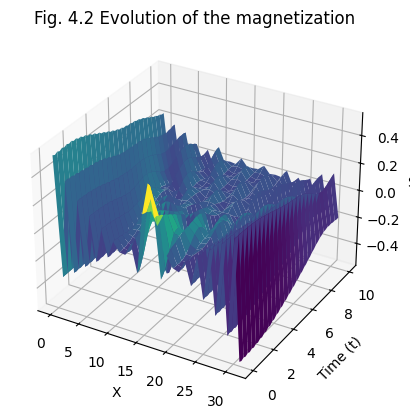

In [78]:
# stride = max(1, (time_slice+1)//300)
# t_idx = np.arange(0,time_slice + 1, 1)
X = np.outer(np.linspace(0, N - 1, N), np.ones(time_slice + 1))
T = np.outer(np.ones(N), np.linspace(0, tau*time_slice, time_slice + 1))
SzMatrix = np.transpose(np.array(Evolution_Sz).real)
fig = plt.figure()
ax = plt.axes(projection='3d')
ax.plot_surface(X, T, SzMatrix, cmap='viridis', edgecolor='none')
ax.set_xlabel("X")
ax.set_ylabel("Time (t)")
ax.set_zlabel("Sz")
# plt.rcParams['font.family'] = 'sans-serif'
ax.set_title('Fig. 4.2 Evolution of the magnetization')
plt.show()
plt.close()
# fig.savefig("Evolution of the magnetization_me")


## 5. Spectral function via Fourier transformation of time-dependence correlation function

In quantum mechanics, time and energy/frequency are Fourier conjugates. The spectral function, S($\omega$), mathematically represents the Fourier transform of a time-dependent correlation function, such as that by time-dependence Green's function (TDGF) as well as corresponding operators G(t) = $\langle \hat{O}(t) \hat{O}(0) \rangle = \int d\omega S(\omega) e^{-\tau \omega}   $ and TEBD:
$$
S(\omega,k) = \int\int dx dt e^{-ikx} e^{i\omega t} \langle S^-(x,t)S^+(\frac{L}{2},0) \rangle.
$$
They could be summarized as:
1. TDGF bases on analytical decoupling scheme but TEBD is puly numerical;
2. TDGF makes approximation on interaction but TEBD truncates the dimension and limits the entanglement;
3. TDGF is operator-based but TEBD is state-based;  
4. TDGF is highly effective for identifying specific interaction processes (like magnon-magnon scattering or Landau damping) but can miss complex, non-perturbative quantum effects. TEBD naturally captures all correlation effects—including multi-magnon continuum hybridization and spontaneous decay—without requiring a priori assumptions about which interaction terms are dominant.
5. TDGF provides a continuous frequency spectrum. Damping and spectral broadening are typically modeled by adding an explicit phenomenological imaginary part (a broadening factor $\eta$ or self-energy $\Sigma $ to the frequency. TEBD yields discrete frequency data based on the finite total time window of the simulation. The maximum propagation time bounds the spectral resolution (e.g., $\Delta \omega \approx \frac{2\pi}{T_{\text{max}}}$). To avoid truncation artifacts, the time series data usually requires windowing functions (such as gaussian window) or linear prediction methods.
6. They could be used together.

For calculating the time-depenence correlation, we perturbate the MPS by a local operator at initial time t=0:
$$
|\Psi(0)^{\alpha}\rangle = S^{\alpha}|Gs\rangle .
$$
Then we get the aother side by
$$
|\Psi(t)^{\beta}\rangle = e^{-i\hat{H}\tau}S^{\beta}|Gs\rangle .
$$
The correlation function is calculated by:
$$
\langle\Psi(t)^{\beta}|\Psi(0)^{\alpha}\rangle  .
$$

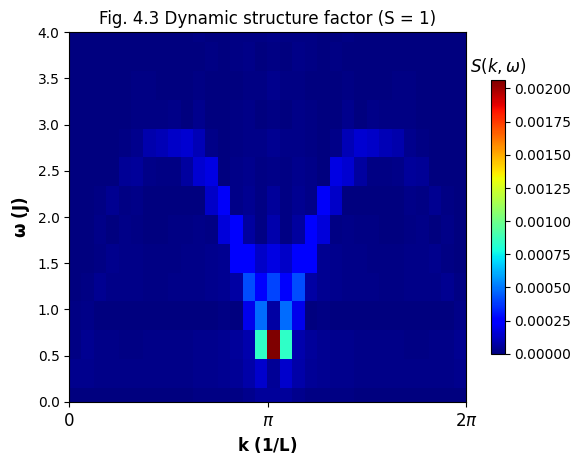

In [79]:
phase_factor = [np.exp(Energy*1j*tau*i) for i in range(-time_slice,time_slice+1)]

Correlation = np.transpose(np.array(Correlation_SpSm))
Correlation = np.concatenate((np.flip(Correlation[:, 1:].conjugate(), axis=1), Correlation), axis=1)
Correlation = Correlation @ np.diag(phase_factor)
# eta = 2.0 / (tau * time_slice)
# Correlation = Correlation * np.exp(-eta * np.abs(tau * np.arange(-time_slice, time_slice + 1)))

Correlation = np.fft.ifftshift(Correlation, axes=1)
Spec = np.absolute(np.fft.fft(np.fft.ifft(Correlation, axis=1), axis=0))
Spec = Spec/np.size(Spec)

NumOmega = Correlation.shape[1]
domega = 2 * np.pi / (NumOmega * tau)
n_pos = NumOmega // 2 + 1
omega = domega * np.arange(n_pos)
Spec = Spec[:, :n_pos]

fig, ax = plt.subplots()
im = ax.imshow(abs(Spec).T, interpolation='none', cmap="jet",
               origin='lower', aspect='auto',
               extent=[0, 2 * np.pi, omega[0] - domega / 2, omega[-1] + domega / 2],
               vmax=abs(Spec).max(), vmin=0)
ax.set_ylim(0,4)
# ax.set_ylim(0, omega[-1] + domega / 2)

plt.xticks([0, np.pi, 2 * np.pi], ['0', r"$\pi$", r"$2\pi$"], fontsize=12)
plt.xlabel(r'$\mathbf{k \ (1/L)}$', fontsize=12)
plt.ylabel(r'$\mathbf{\omega \ (J)}$', fontsize=12)
cbar = fig.colorbar(im, ax=ax,shrink = 0.74)
cbar.ax.set_title(r'$S(k,\omega)$')

ax.set_title(r'Fig. 4.3 Dynamic structure factor (S = 1)')
plt.show()

We put the spectrum of half spin chian here for reference

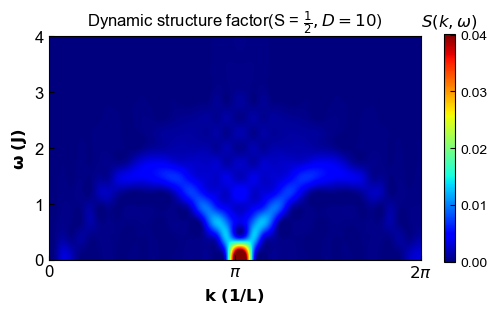

It is clear that S = 1 chain is gapped